In [180]:
import matplotlib.pyplot as plt

In [181]:
%matplotlib inline

In [182]:
import numpy as np

In [183]:
import healpy as hp

In [184]:
NSIDE = 32
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 32 is 1.8 deg


In [185]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

12288


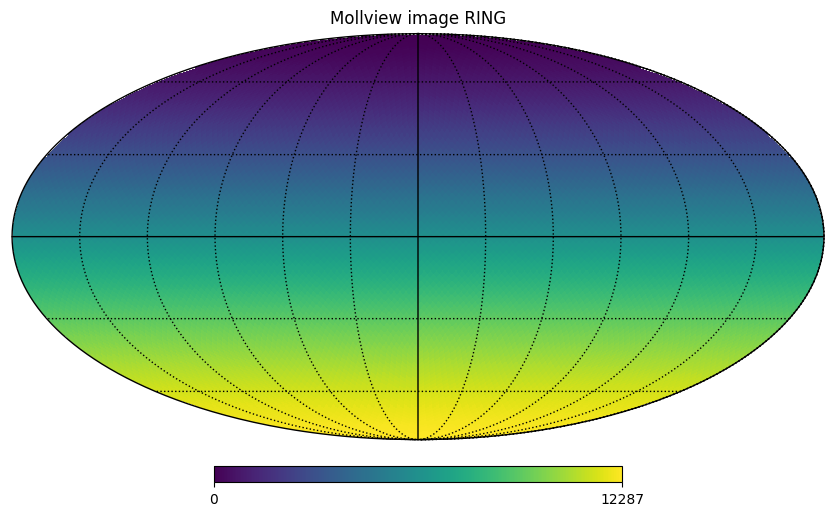

In [186]:
m = np.arange(NPIX)
hp.mollview(m, title="Mollview image RING")
hp.graticule()

In [187]:
vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4)
print(vec)

[-7.07106781e-01  7.07106781e-01  6.12323400e-17]


In [188]:
ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10))

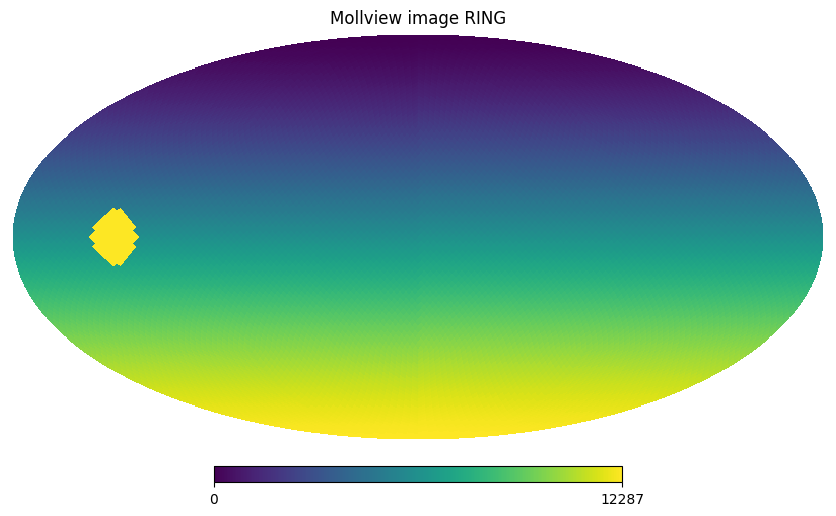

In [189]:
m = np.arange(NPIX)
m[ipix_disc] = m.max()
hp.mollview(m, title="Mollview image RING")

In [190]:
theta, phi = np.degrees(hp.pix2ang(nside=32, ipix=[0, 1, 2, 3, 4]))

In [191]:
theta

array([1.46197116, 1.46197116, 1.46197116, 1.46197116, 2.92418036])

In [192]:
phi

array([ 45. , 135. , 225. , 315. ,  22.5])

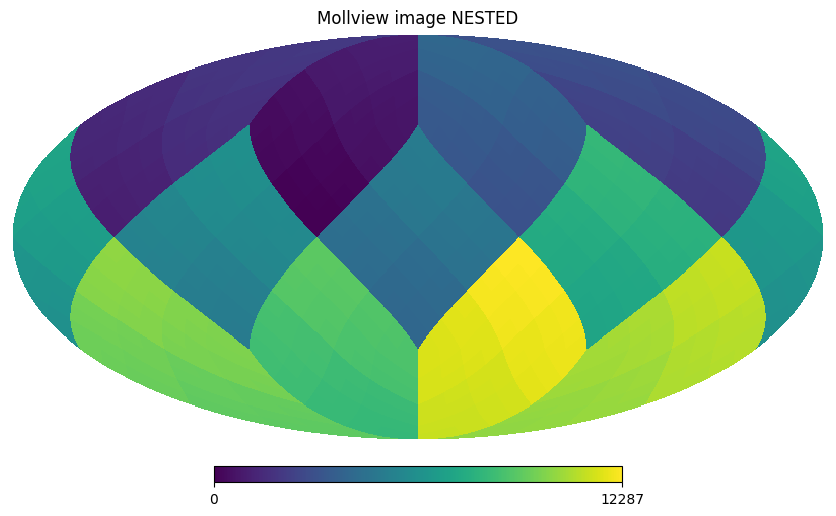

In [193]:
m = np.arange(NPIX)
hp.mollview(m, nest=True, title="Mollview image NESTED")

In [194]:
!wget -c http://lambda.gsfc.nasa.gov/data/map/dr4/skymaps/7yr/raw/wmap_band_iqumap_r9_7yr_W_v4.fits;wget -c http://lambda.gsfc.nas.gov/data/map/dr4/ancillary/mask/wmap_temperature_analysis_mask_r9_7yr_v4.fits

URL transformed to HTTPS due to an HSTS policy
--2025-12-01 15:47:38--  https://lambda.gsfc.nasa.gov/data/map/dr4/skymaps/7yr/raw/wmap_band_iqumap_r9_7yr_W_v4.fits
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2025-12-01 15:47:38--  http://lambda.gsfc.nas.gov/data/map/dr4/ancillary/mask/wmap_temperature_analysis_mask_r9_7yr_v4.fits
Resolving lambda.gsfc.nas.gov (lambda.gsfc.nas.gov)... failed: nodename nor servname provided, or not known.
wget: unable to resolve host address ‘lambda.gsfc.nas.gov’


In [195]:
wmap_map_I = hp.read_map("wmap_band_iqumap_r9_7yr_W_v4.fits")

In [196]:
hp.write_map("my_map.fits", wmap_map_I, overwrite=True)

setting the output map dtype to [dtype('>f4')]


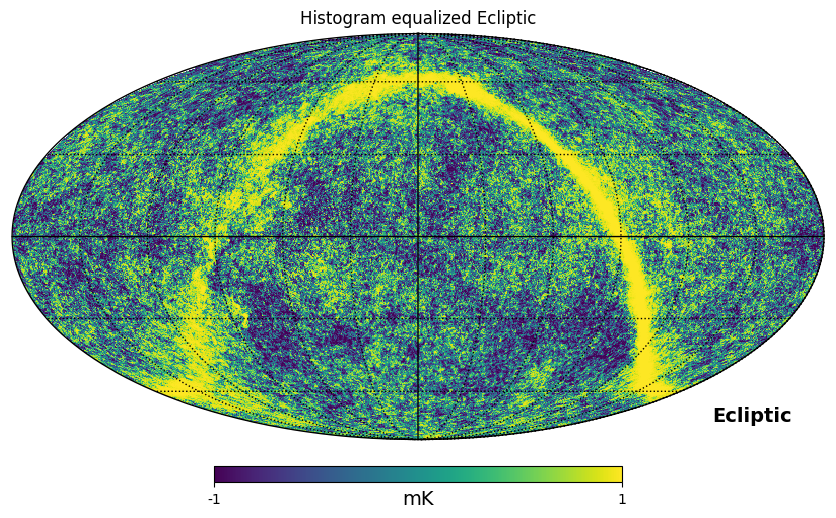

In [197]:
hp.mollview(
    wmap_map_I,
    coord=["G", "E"],
    title="Histogram equalized Ecliptic",
    unit="mK",
    norm="hist",
    min=-1,
    max=1,
)
hp.graticule()

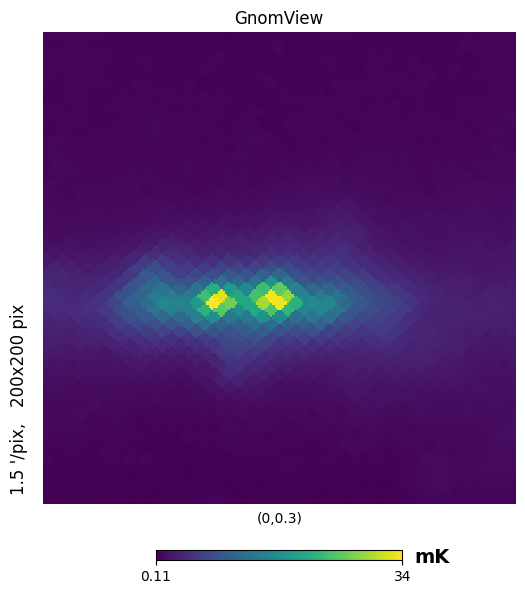

In [198]:
hp.gnomview(wmap_map_I, rot=[0, 0.3], title="GnomView", unit="mK", format="%.2g")

In [199]:
!wget -c https://lambda.gsfc.nasa.gov/data/map/dr4/ancillary/masks/wmap_temperature_analysis_mask_r9_7yr_v4.fits


--2025-12-01 15:47:39--  https://lambda.gsfc.nasa.gov/data/map/dr4/ancillary/masks/wmap_temperature_analysis_mask_r9_7yr_v4.fits
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [200]:
mask = hp.read_map("wmap_temperature_analysis_mask_r9_7yr_v4.fits").astype(np.bool_)
wmap_map_I_masked = hp.ma(wmap_map_I)
wmap_map_I_masked.mask = np.logical_not(mask)

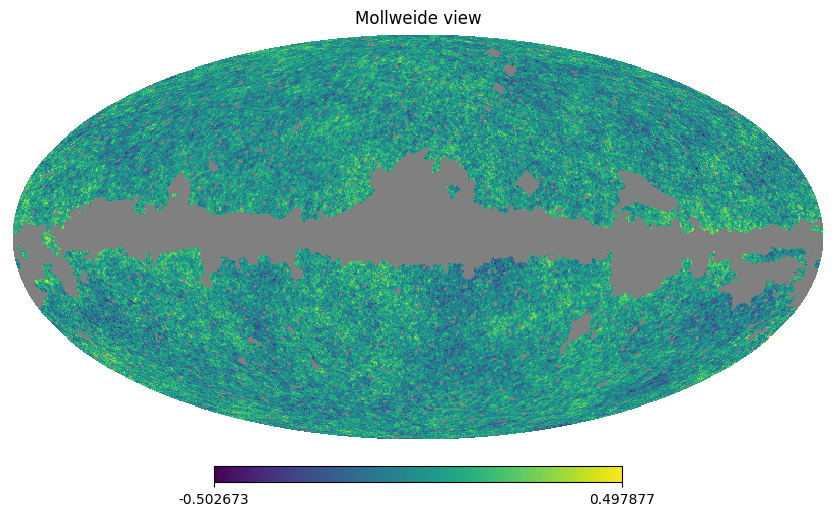

In [201]:
hp.mollview(wmap_map_I_masked.filled())


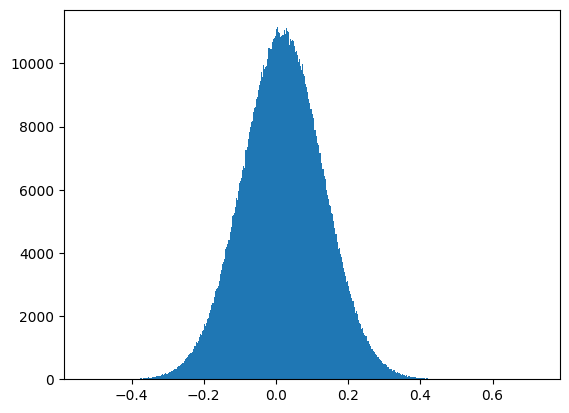

In [202]:
plt.hist(wmap_map_I_masked.compressed(), bins=1000);

In [203]:
LMAX = 1024
cl = hp.anafast(wmap_map_I_masked.filled(), lmax=LMAX)
ell = np.arange(len(cl))

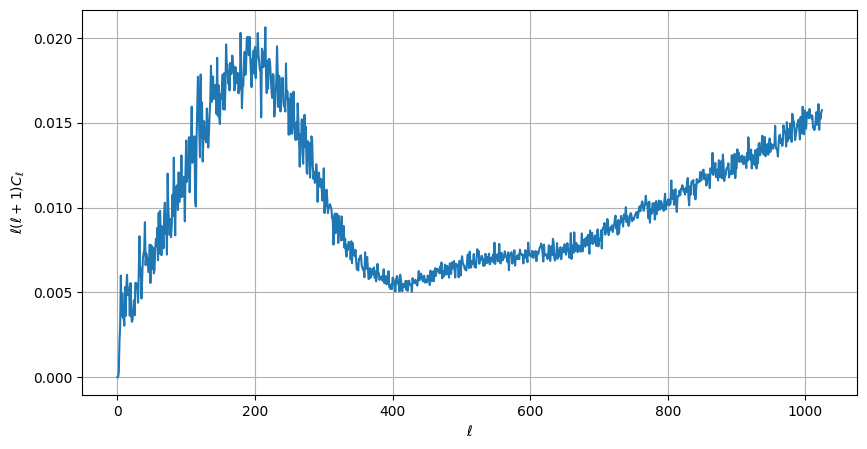

In [204]:
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl)
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()
hp.write_cl("cl.fits", cl, overwrite=True)

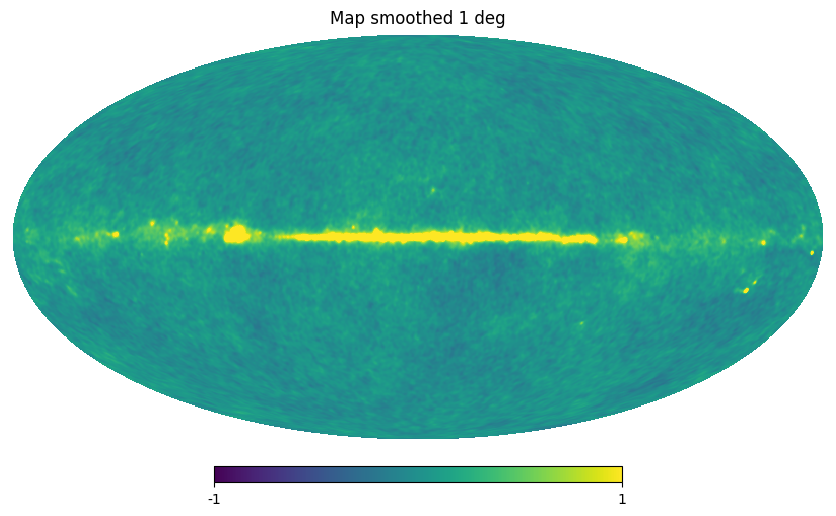

In [205]:
wmap_map_I_smoothed = hp.smoothing(wmap_map_I, fwhm=np.radians(1.))
hp.mollview(wmap_map_I_smoothed, min=-1, max=1, title="Map smoothed 1 deg")

In [207]:
fits_file_path = "/Users/aydenyun/Documents/Cosmic Technology/Cosmic Technology/LFI_SkyMap_070_1024_R3.00_full.fits"

In [208]:
I, Q, U = hp.read_map(fits_file_path, field=(0,1,2))

In [209]:
NSIDE = hp.get_nside(I)

In [210]:
print("Loaded map. NSIDE =", NSIDE)

Loaded map. NSIDE = 1024


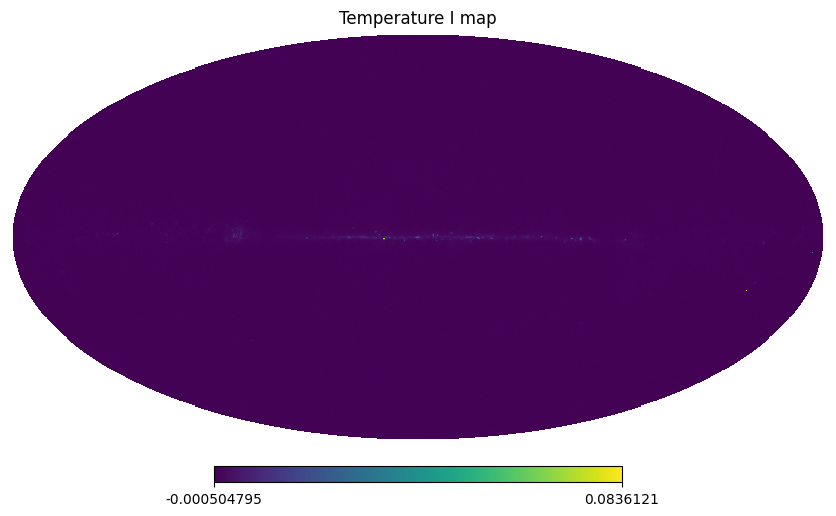

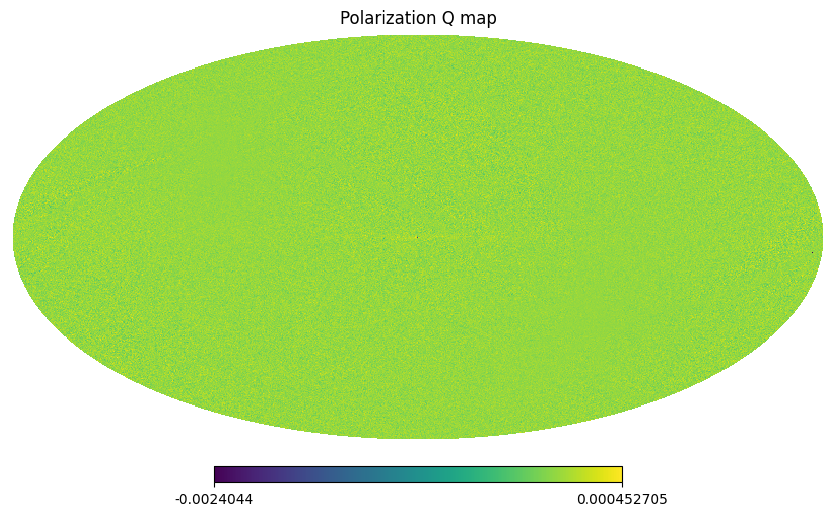

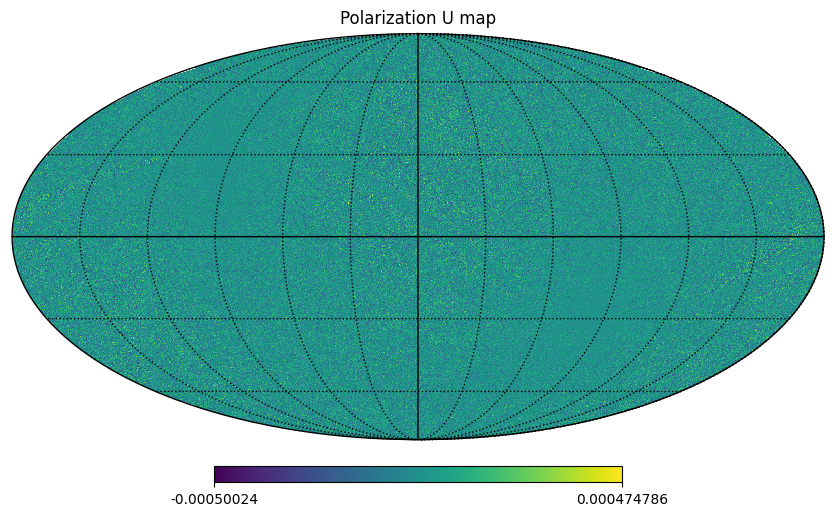

In [211]:
hp.mollview(I, title="Temperature I map")
hp.mollview(Q, title="Polarization Q map")
hp.mollview(U, title="Polarization U map")
hp.graticule()

In [212]:
mask = np.ones_like(I).astype(bool)  # no mask

In [214]:
#Apply to polarization:

Qm = hp.ma(Q)
Um = hp.ma(U)
Qm.mask = ~mask
Um.mask = ~mask

In [215]:
LMAX = 3*NSIDE - 1

almE, almB = hp.map2alm_spin([Qm.filled(), Um.filled()], spin=2, lmax=LMAX)


In [216]:
cl_EE = hp.alm2cl(almE, almE)
cl_BB = hp.alm2cl(almB, almB)
cl_EB = hp.alm2cl(almE, almB)

ell = np.arange(len(cl_EE))

Text(0.5, 1.0, 'Polarization Spectra from 70 GHz map')

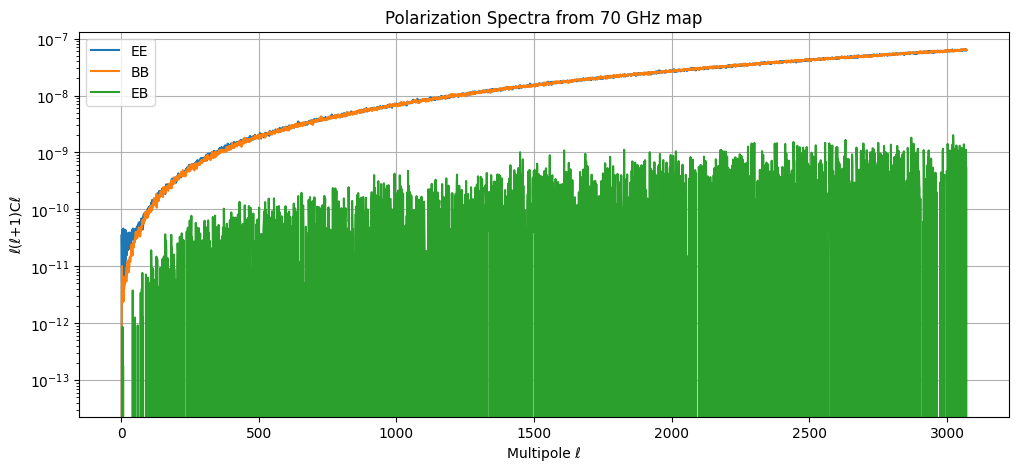

In [217]:
plt.figure(figsize=(12,5))
plt.plot(ell, ell*(ell+1)*cl_EE, label="EE")
plt.plot(ell, ell*(ell+1)*cl_BB, label="BB")
plt.plot(ell, ell*(ell+1)*cl_EB, label="EB")
plt.xlabel("Multipole ℓ")
plt.ylabel("ℓ(ℓ+1)Cℓ")
plt.yscale("log")
plt.legend()
plt.grid()
plt.title("Polarization Spectra from 70 GHz map")

In [218]:
hp.write_cl("Cl_70GHz_EE_BB_EB.fits",
            [cl_EE, cl_BB, cl_EB],
            overwrite=True)
print("Saved: Cl_70GHz_EE_BB_EB.fits")

Saved: Cl_70GHz_EE_BB_EB.fits


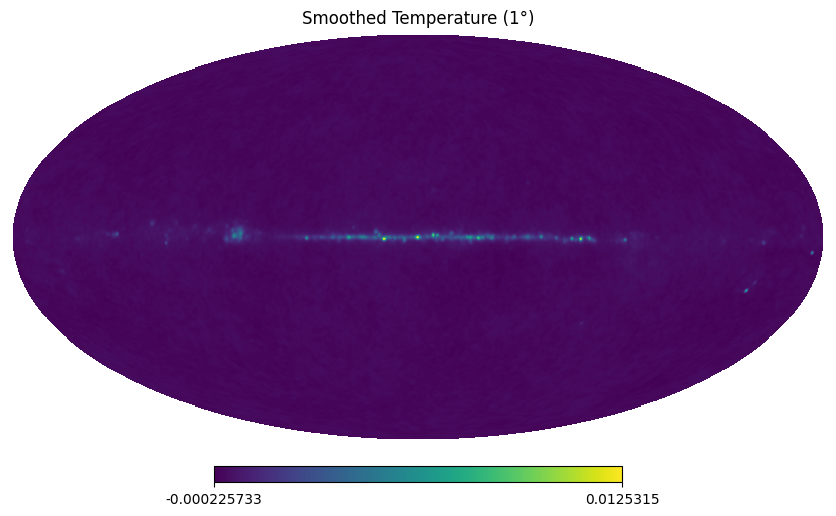

In [219]:
I_smooth = hp.smoothing(I, fwhm=np.radians(1.0))
hp.mollview(I_smooth, title="Smoothed Temperature (1°)")

In [1]:
#20251201